# Fraud EDA with Spark

Exploratory analysis of fraud patterns: class imbalance, amounts by label, and fraud concentration by transaction type. All aggregations run in Spark; only small summaries are collected for plotting.

**Prerequisites:** `make sample-data` and `make ingest`.

In [1]:
from transaction_risk.spark.session import create_spark_session_from_yaml
spark = create_spark_session_from_yaml('../conf/spark.local.yaml')


In [2]:
from pyspark.sql import functions as F

from transaction_risk.spark.io import read_table

transactions = read_table(spark, '../data/silver/transactions')

label_counts = transactions.groupBy('isFraud').count().orderBy('isFraud').collect()
amount_by_label = (
    transactions.groupBy('isFraud')
    .agg(
        F.avg('amount').alias('mean_amount'),
        F.expr('percentile_approx(amount, 0.5)').alias('median_amount'),
        F.max('amount').alias('max_amount'),
    )
    .orderBy('isFraud')
)
amount_by_label.show()

+-------+------------------+-------------+----------+
|isFraud|       mean_amount|median_amount|max_amount|
+-------+------------------+-------------+----------+
|      0| 5298.173090687277|       3810.4|  43597.12|
|      1|114925.19695121952|    115375.67| 242477.84|
+-------+------------------+-------------+----------+



In [3]:
# Fraud rate by transaction type — fraud concentrates in TRANSFER and CASH_OUT in PaySim-like data
fraud_by_type = (
    transactions.groupBy('type')
    .agg(F.count(F.lit(1)).alias('transactions'), F.avg(F.col('isFraud').cast('double')).alias('fraud_rate'))
    .orderBy(F.col('fraud_rate').desc())
)
fraud_by_type.show()

+--------+------------+--------------------+
|    type|transactions|          fraud_rate|
+--------+------------+--------------------+
|TRANSFER|         840| 0.02738095238095238|
|CASH_OUT|        1086|0.020257826887661142|
| PAYMENT|        2107|0.013289036544850499|
|   DEBIT|         387|  0.0103359173126615|
| CASH_IN|         580|0.008620689655172414|
+--------+------------+--------------------+



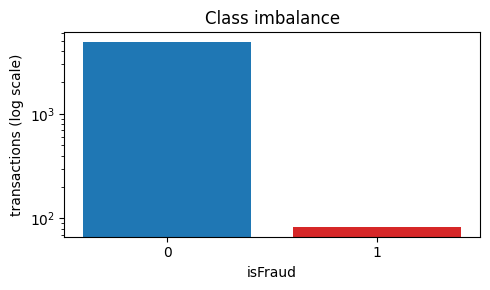

In [4]:
import matplotlib.pyplot as plt

labels = [str(row['isFraud']) for row in label_counts]
counts = [row['count'] for row in label_counts]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, counts, color=['tab:blue', 'tab:red'])
ax.set_yscale('log')
ax.set_xlabel('isFraud')
ax.set_ylabel('transactions (log scale)')
ax.set_title('Class imbalance')
plt.tight_layout()
plt.show()
spark.stop()